# Gaussian Process Regression using Scikit-Learn for Battery State-of-Health (SOH) Prediction

This notebook presents a comprehensive implementation of **Gaussian Process Regression (GPR) using Scikit-Learn** to estimate the State-of-Health (SOH) of Li-ion batteries based on NASA aging datasets. We use `scikit-learn`'s built-in GPR, kernels, and standard baseline machine learning models for comparison.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, DotProduct, ConstantKernel, WhiteKernel


## 2. Dataset Ingestion and Structure Inspection

We load the raw MATLAB `.mat` data structure for battery unit **B0005** to inspect its layout.


In [2]:
mat = loadmat("Battery_DataSet/B0005.mat")
print(mat.keys())


dict_keys(['__header__', '__version__', '__globals__', 'B0005'])


In [3]:
battery = mat["B0005"]
cycles = battery[0,0]["cycle"][0]
print("Data Type:", type(battery))
print("Shape:", battery.shape)
print("Fields in battery struct:", battery[0,0].dtype.names)
print("Number of cycles in dataset:", len(cycles))


Data Type: <class 'numpy.ndarray'>
Shape: (1, 1)
Fields in battery struct: ('cycle',)
Number of cycles in dataset: 616


In [4]:
capacity_data = []
cycle_num = 1
for cycle in cycles:
    if cycle["type"][0] == "discharge":
        capacity = cycle["data"][0,0]["Capacity"][0,0]
        capacity_data.append([cycle_num, capacity])
        cycle_num += 1


In [5]:
df = pd.DataFrame(capacity_data, columns=["Cycle", "Capacity"])
df.to_csv("B0005_SOH.csv", index=False)
print(df.head())


   Cycle  Capacity
0      1  1.856487
1      2  1.846327
2      3  1.835349
3      4  1.835263
4      5  1.834646


### 2.1 SOH Calculation and Feature Engineering

The State of Health (SOH) is calculated as the ratio of current capacity to the initial nominal capacity.


In [6]:
initial_capacity = df["Capacity"].iloc[0]
df["SOH"] = df["Capacity"] / initial_capacity
print(df.head())


   Cycle  Capacity       SOH
0      1  1.856487  1.000000
1      2  1.846327  0.994527
2      3  1.835349  0.988614
3      4  1.835263  0.988567
4      5  1.834646  0.988235


### 2.2 Visualizing SOH Degradation Curve

We plot the SOH degradation over cycle numbers.


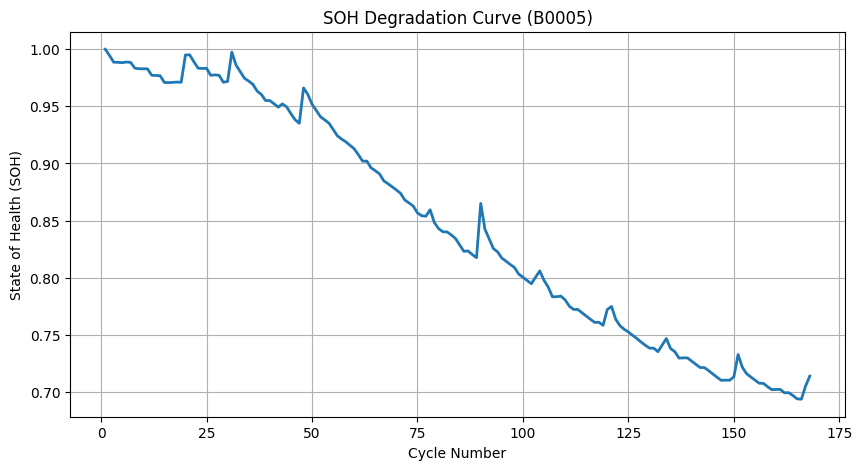

In [7]:
plt.figure(figsize=(10,5))
plt.plot(df["Cycle"], df["SOH"], linewidth=2)
plt.xlabel("Cycle Number")
plt.ylabel("State of Health (SOH)")
plt.title("SOH Degradation Curve (B0005)")
plt.grid(True)
plt.show()


### 2.3 Reshaping Features and Targets for GPR


In [8]:
X = df["Cycle"].values.reshape(-1,1)
y = df["SOH"].values


### 2.4 Chronological Train-Test Split (70/30)


In [9]:
split_idx = int(0.7 * len(X))
X_train = X[:split_idx]
y_train = y[:split_idx]
X_test = X[split_idx:]
y_test = y[split_idx:]


In [10]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (117, 1)
Test size: (51, 1)


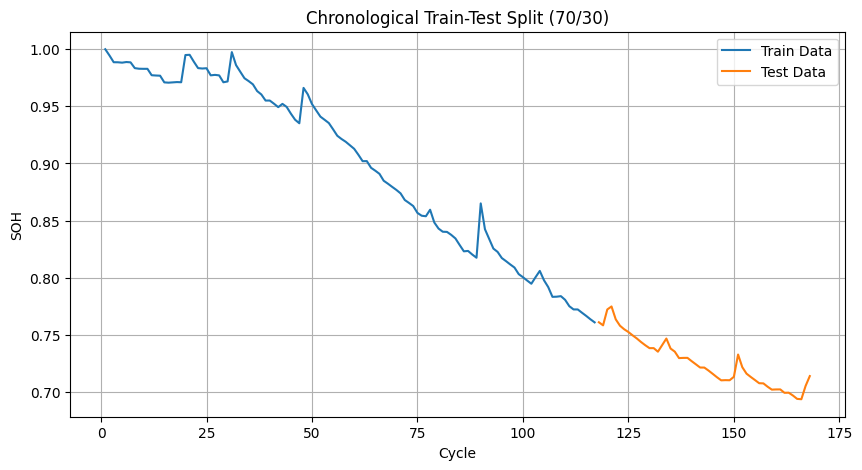

In [11]:
plt.figure(figsize=(10,5))
plt.plot(X_train, y_train, label="Train Data")
plt.plot(X_test, y_test, label="Test Data")
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.title("Chronological Train-Test Split (70/30)")
plt.legend()
plt.grid(True)
plt.show()


### 2.6 Calculating Observation Noise Variance from Dataset

Following standard regression methodology, we estimate the observation noise variance ($\sigma_n^2$) by fitting a linear degradation trend to the training SOH data and calculating the variance of the residuals.


In [12]:
# Fit a linear trend to the training dataset SOH to estimate noise residuals
p = np.polyfit(X_train.flatten(), y_train, 1)
y_trend = np.polyval(p, X_train.flatten())
noise = np.var(y_train - y_trend)
print("Calculated Noise Variance (sigma_n^2):", noise)


Calculated Noise Variance (sigma_n^2): 0.00028668131319509665


## 3. GPR Implementation with Squared Exponential (RBF) Kernel

We implement the Constant*RBF + WhiteKernel and train it using Scikit-Learn.


In [13]:
kernel = ConstantKernel(1.0, "fixed") * RBF(length_scale=100.0, length_scale_bounds="fixed")


In [14]:
y_train_mean = np.mean(y_train)
y_train_centered = y_train - y_train_mean
gpr = GaussianProcessRegressor(kernel=kernel, alpha=noise, optimizer=None, normalize_y=False, random_state=42)
gpr.fit(X_train, y_train_centered)
print("Learned Kernel (Fixed):", gpr.kernel_)


Learned Kernel (Fixed): 1**2 * RBF(length_scale=100)


In [15]:
posterior_mean, posterior_std = gpr.predict(X_test, return_std=True)
posterior_mean = posterior_mean + y_train_mean
posterior_variance = posterior_std ** 2
lower = posterior_mean - 1.96 * posterior_std
upper = posterior_mean + 1.96 * posterior_std


In [16]:
print("Posterior Mean Shape:", posterior_mean.shape)
print("Posterior Std Shape:", posterior_std.shape)


Posterior Mean Shape: (51,)
Posterior Std Shape: (51,)


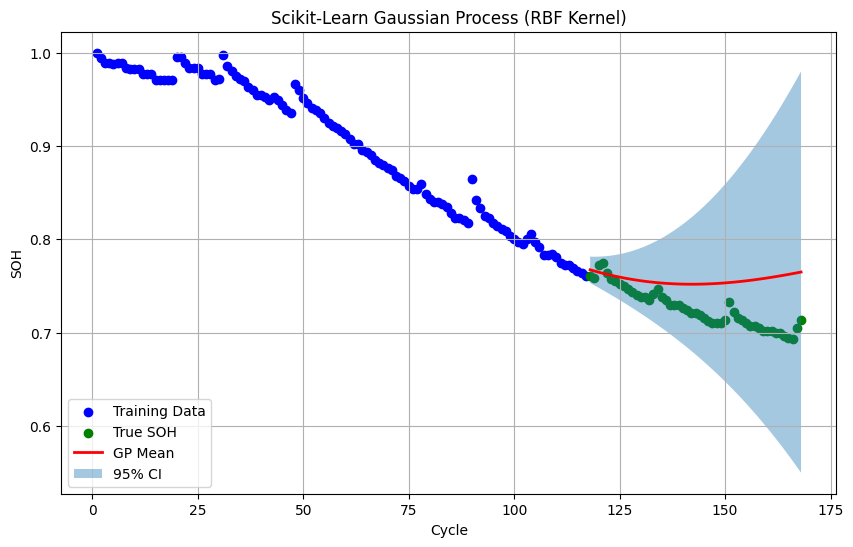

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(X_train, y_train, color="blue", label="Training Data")
plt.scatter(X_test, y_test, color="green", label="True SOH")
plt.plot(X_test, posterior_mean, color="red", linewidth=2, label="GP Mean")
plt.fill_between(X_test.flatten(), lower, upper, alpha=0.4, label="95% CI")
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.title("Scikit-Learn Gaussian Process (RBF Kernel)")
plt.legend()
plt.grid(True)
plt.show()


### 3.4 Quantifying Prediction Performance (RMSE, MAE, R²)


In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
rmse = np.sqrt(mean_squared_error(y_test, posterior_mean))
mae = mean_absolute_error(y_test, posterior_mean)
r2 = r2_score(y_test, posterior_mean)
print("RMSE =", rmse)
print("MAE =", mae)
print("R2 =", r2)


RMSE = 0.03701424298509152
MAE = 0.031360278413339576
R2 = -2.0065550991666967


### 3.5 Calculating Negative Log Likelihood (NLL)

We calculate the NLL under the predictive Gaussian distribution using Scipy.


In [19]:
from scipy.stats import norm
nll = -np.mean(norm.logpdf(y_test, loc=posterior_mean, scale=posterior_std))
print("NLL =", nll)


NLL = -2.1732954881632267


## 4. Extrapolative SOH Forecasting (RBF Kernel)


In [20]:
future_cycles = np.arange(X.max()+1, X.max()+201).reshape(-1,1)
future_mean, future_std = gpr.predict(future_cycles, return_std=True)
future_mean = future_mean + y_train_mean
future_lower = future_mean - 1.96 * future_std
future_upper = future_mean + 1.96 * future_std


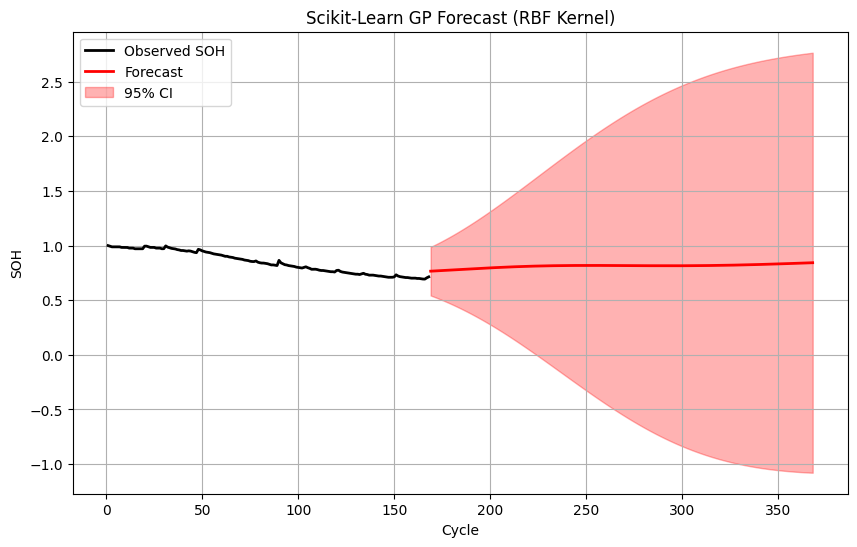

In [21]:
plt.figure(figsize=(10,6))
plt.plot(df["Cycle"], df["SOH"], label="Observed SOH", color="black", linewidth=2)
plt.plot(future_cycles, future_mean, linewidth=2, label="Forecast", color="red")
plt.fill_between(future_cycles.flatten(), future_lower, future_upper, alpha=0.3, label="95% CI", color="red")
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.title("Scikit-Learn GP Forecast (RBF Kernel)")
plt.legend()
plt.grid(True)
plt.show()


## 5. Comparison of Covariance Functions (GPML Chapter 4)

We set up a dictionary of six GPR kernels in Scikit-Learn.


In [22]:
kernels = {
    "RBF": ConstantKernel(1.0, "fixed") * RBF(length_scale=100.0, length_scale_bounds="fixed"),
    "Matern32": ConstantKernel(1.0, "fixed") * Matern(length_scale=100.0, length_scale_bounds="fixed", nu=1.5),
    "Matern52": ConstantKernel(1.0, "fixed") * Matern(length_scale=100.0, length_scale_bounds="fixed", nu=2.5),
    "RQ": ConstantKernel(1.0, "fixed") * RationalQuadratic(length_scale=100.0, length_scale_bounds="fixed", alpha=1.0, alpha_bounds="fixed"),
    "Linear": ConstantKernel(1.0, "fixed") * DotProduct(sigma_0=1.0, sigma_0_bounds="fixed"),
    "RBF+Linear": ConstantKernel(1.0, "fixed") * (RBF(length_scale=100.0, length_scale_bounds="fixed") + DotProduct(sigma_0=1.0, sigma_0_bounds="fixed"))
}


In [23]:
results = {}
y_train_mean = np.mean(y_train)
y_train_centered = y_train - y_train_mean
for name, kernel in kernels.items():
    gpr_k = GaussianProcessRegressor(kernel=kernel, alpha=noise, optimizer=None, normalize_y=False, random_state=42)
    gpr_k.fit(X_train, y_train_centered)
    mean, std = gpr_k.predict(X_test, return_std=True)
    mean = mean + y_train_mean
    results[name] = {
        "mean": mean,
        "std": std,
        "model": gpr_k
    }
    print(f"Scikit-Learn GP with {name} kernel trained.")


Scikit-Learn GP with RBF kernel trained.
Scikit-Learn GP with Matern32 kernel trained.
Scikit-Learn GP with Matern52 kernel trained.
Scikit-Learn GP with RQ kernel trained.
Scikit-Learn GP with Linear kernel trained.
Scikit-Learn GP with RBF+Linear kernel trained.


In [24]:
comparison = []
for name in results.keys():
    pred = results[name]["mean"]
    std = results[name]["std"]
    
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    nll = -np.mean(norm.logpdf(y_test, loc=pred, scale=std))
    
    comparison.append([name, rmse, mae, r2, nll])

comparison_df = pd.DataFrame(
    comparison,
    columns=["Kernel", "RMSE", "MAE", "R2", "NLL"]
)
comparison_df = comparison_df.sort_values("RMSE")
print(comparison_df)


       Kernel      RMSE       MAE         R2       NLL
2    Matern52  0.010081  0.008278   0.776997 -1.219370
4      Linear  0.016611  0.012155   0.394470  1.355191
1    Matern32  0.022418  0.017339  -0.102845 -0.641342
5  RBF+Linear  0.031424  0.026950  -1.167041 -2.162582
0         RBF  0.037014  0.031360  -2.006555 -2.173295
3          RQ  0.087043  0.073158 -15.626521 -1.424796


In [25]:
variance_summary = []
for name in results.keys():
    std = results[name]["std"]
    variance = std ** 2
    variance_summary.append([
        name,
        np.mean(variance),
        np.max(variance),
        variance[-1]
    ])
variance_df = pd.DataFrame(
    variance_summary,
    columns=["Kernel", "Avg Variance", "Max Variance", "Final Variance"]
)
print(variance_df)


       Kernel  Avg Variance  Max Variance  Final Variance
0         RBF      0.002993      0.012047        0.012047
1    Matern32      0.099828      0.281711        0.281711
2    Matern52      0.037810      0.133375        0.133375
3          RQ      0.011341      0.046059        0.046059
4      Linear      0.000018      0.000028        0.000028
5  RBF+Linear      0.003946      0.016684        0.016684


In [26]:
forecast_results = {}
for name in results.keys():
    model = results[name]["model"]
    mean, std = model.predict(future_cycles, return_std=True)
    mean = mean + y_train_mean
    forecast_results[name] = {
        "mean": mean,
        "variance": std ** 2
    }


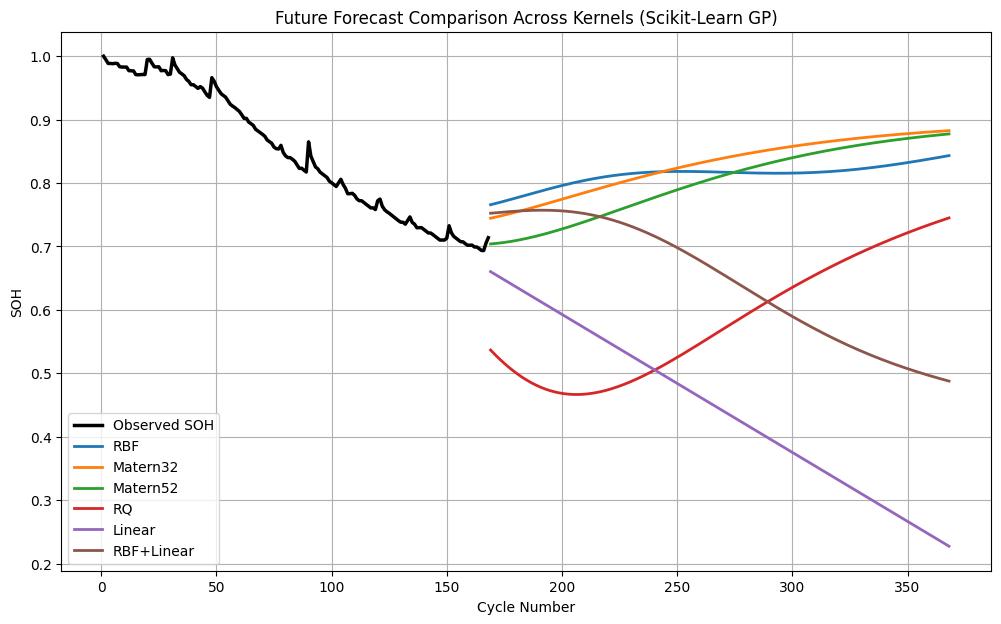

In [27]:
plt.figure(figsize=(12,7))
plt.plot(df["Cycle"], df["SOH"], color="black", linewidth=2.5, label="Observed SOH")
for name in forecast_results.keys():
    plt.plot(future_cycles, forecast_results[name]["mean"], linewidth=2, label=name)
plt.xlabel("Cycle Number")
plt.ylabel("SOH")
plt.title("Future Forecast Comparison Across Kernels (Scikit-Learn GP)")
plt.legend()
plt.grid(True)
plt.show()


## 6. Comparison with Baseline Machine Learning Models

We implement baseline regressors (Linear Regression, Polynomial Regression, KNN, and Decision Tree) using standard Scikit-Learn implementations.


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

models_baseline = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression (Deg 2)": make_pipeline(PolynomialFeatures(2), LinearRegression()),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

trained_baselines = {}
for name, model in models_baseline.items():
    model.fit(X_train, y_train)
    trained_baselines[name] = model
    print(f"Baseline '{name}' trained successfully.")


Baseline 'Linear Regression' trained successfully.
Baseline 'Polynomial Regression (Deg 2)' trained successfully.
Baseline 'K-Nearest Neighbors' trained successfully.
Baseline 'Decision Tree' trained successfully.


In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

baseline_results = []
for name, model in trained_baselines.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    baseline_results.append([name, rmse, mae, r2, mape])

baseline_df = pd.DataFrame(
    baseline_results,
    columns=["Model", "RMSE", "MAE", "R2", "MAPE"]
)
baseline_df = baseline_df.sort_values("RMSE")
print(baseline_df)


                           Model      RMSE       MAE         R2      MAPE
0              Linear Regression  0.016612  0.012155   0.394415  0.016997
3                  Decision Tree  0.042997  0.038094  -3.056990  0.053286
2            K-Nearest Neighbors  0.045477  0.040704  -3.538513  0.056901
1  Polynomial Regression (Deg 2)  0.089741  0.079783 -16.673283  0.111377


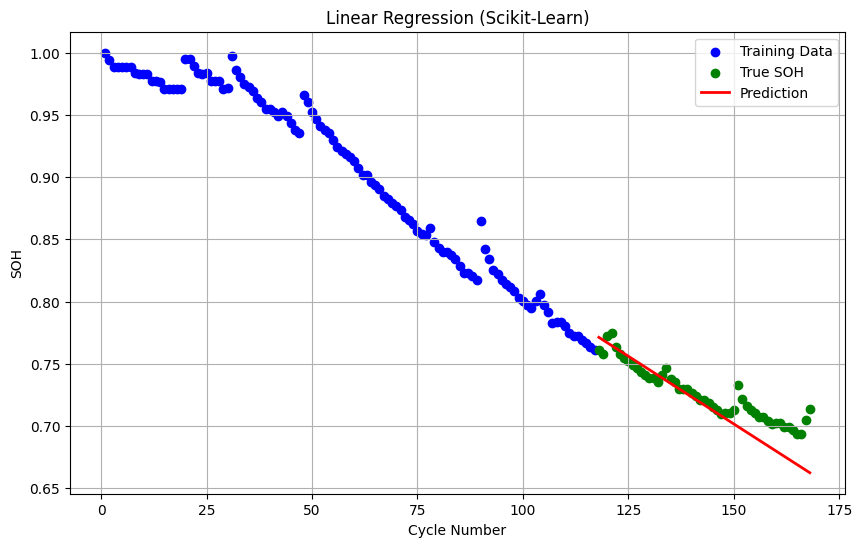

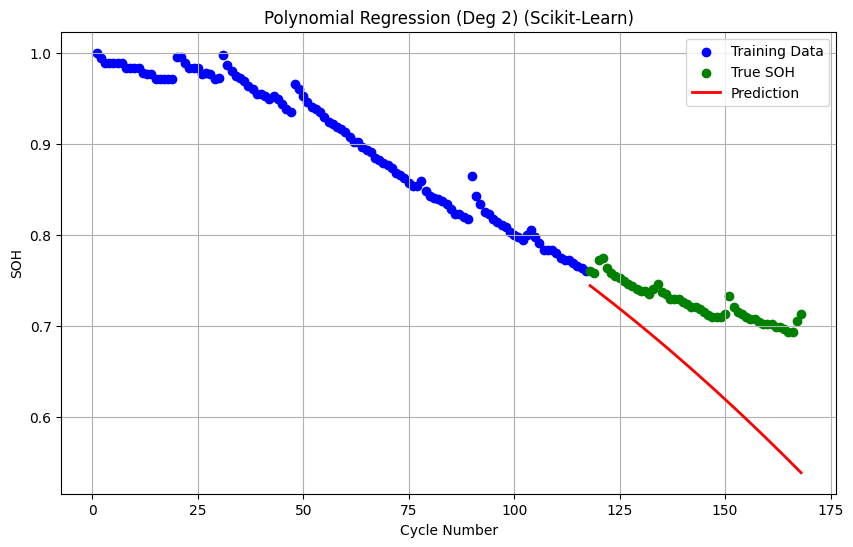

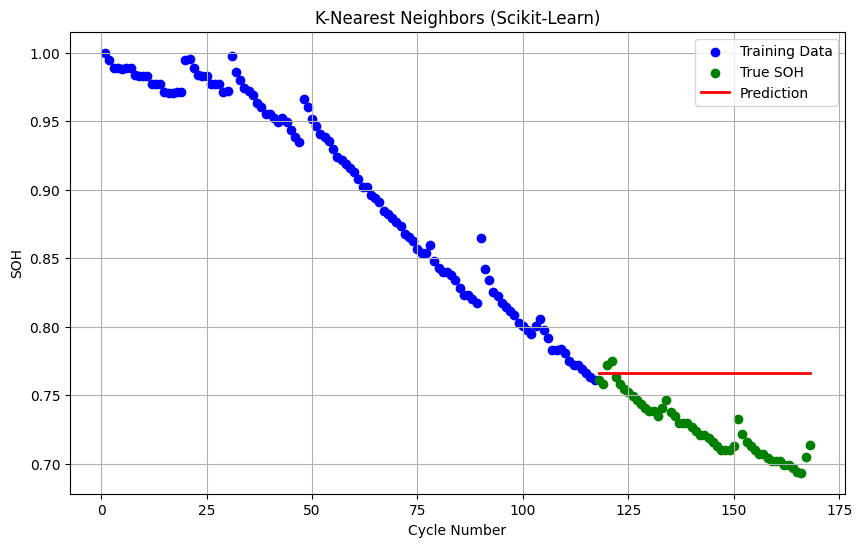

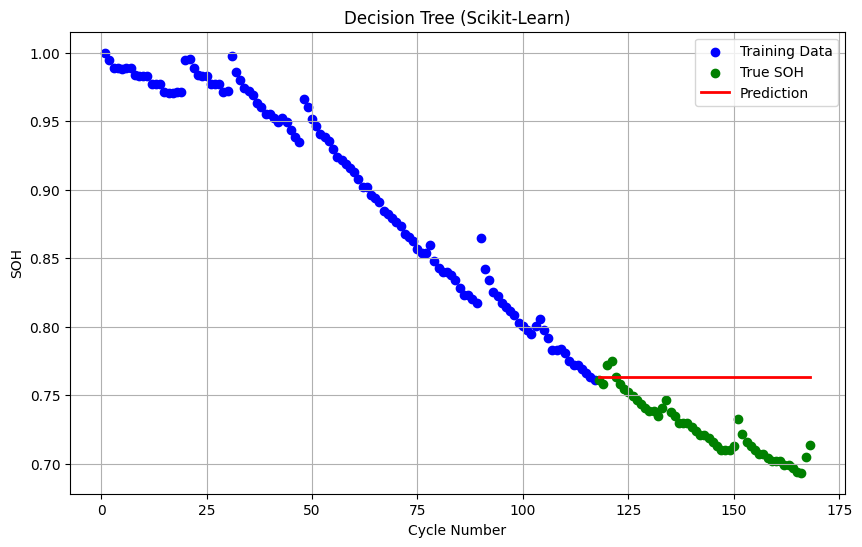

In [30]:
for name, model in trained_baselines.items():
    y_pred = model.predict(X_test)
    plt.figure(figsize=(10,6))
    plt.scatter(X_train, y_train, color='blue', label='Training Data')
    plt.scatter(X_test, y_test, color='green', label='True SOH')
    plt.plot(X_test, y_pred, color='red', linewidth=2, label='Prediction')
    plt.title(f"{name} (Scikit-Learn)")
    plt.xlabel("Cycle Number")
    plt.ylabel("SOH")
    plt.legend()
    plt.grid(True)
    plt.show()


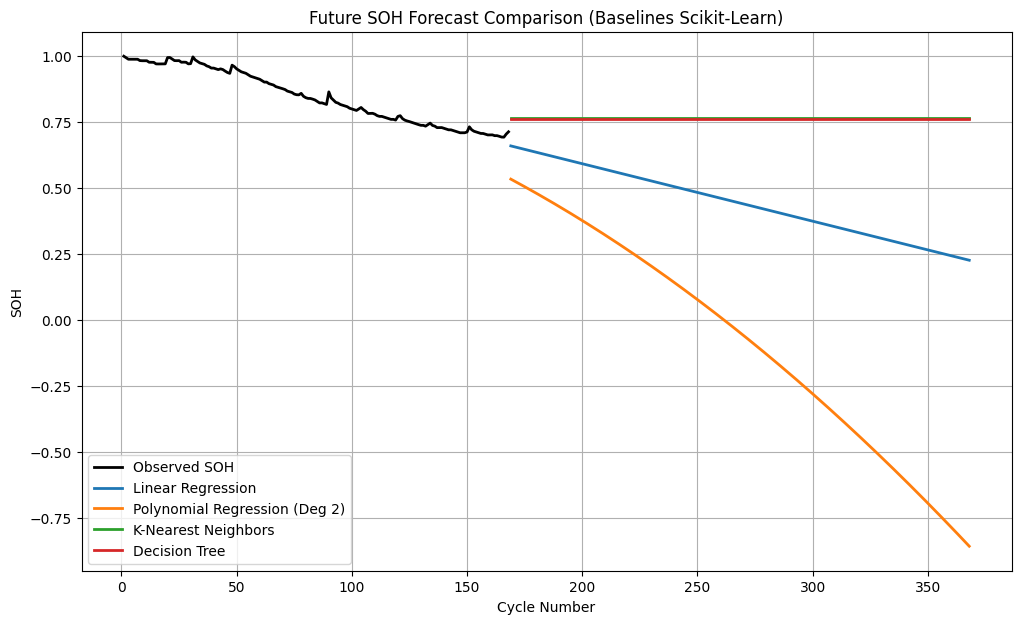

In [31]:
plt.figure(figsize=(12,7))
plt.plot(df["Cycle"], df["SOH"], color='black', linewidth=2, label='Observed SOH')
for name, model in trained_baselines.items():
    future_pred = model.predict(future_cycles)
    plt.plot(future_cycles, future_pred, linewidth=2, label=name)
plt.xlabel("Cycle Number")
plt.ylabel("SOH")
plt.title("Future SOH Forecast Comparison (Baselines Scikit-Learn)")
plt.legend()
plt.grid(True)
plt.show()


## 7. Summary and Model Ranking

We compile a ranking of all implemented Gaussian Process models and baseline regressors, and visualize their test set root-mean-squared error (RMSE) and accuracy.


In [32]:
joint_results = []

# Add GP kernels
for name in results.keys():
    pred = results[name]["mean"]
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = mean_absolute_percentage_error(y_test, pred)
    accuracy = 100 * (1 - mape)
    joint_results.append([f"GPR ({name})", rmse, accuracy])
    
# Add baselines
for name, model in trained_baselines.items():
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = mean_absolute_percentage_error(y_test, pred)
    accuracy = 100 * (1 - mape)
    joint_results.append([name, rmse, accuracy])
    
ranking_df = pd.DataFrame(joint_results, columns=["Model", "RMSE", "Accuracy (%)"])
ranking_df = ranking_df.sort_values("RMSE")
print(ranking_df)


                           Model      RMSE  Accuracy (%)
2                 GPR (Matern52)  0.010081     98.872030
4                   GPR (Linear)  0.016611     98.300362
6              Linear Regression  0.016612     98.300270
1                 GPR (Matern32)  0.022418     97.565889
5               GPR (RBF+Linear)  0.031424     96.223836
0                      GPR (RBF)  0.037014     95.602773
9                  Decision Tree  0.042997     94.671446
8            K-Nearest Neighbors  0.045477     94.309883
3                       GPR (RQ)  0.087043     89.751401
7  Polynomial Regression (Deg 2)  0.089741     88.862255


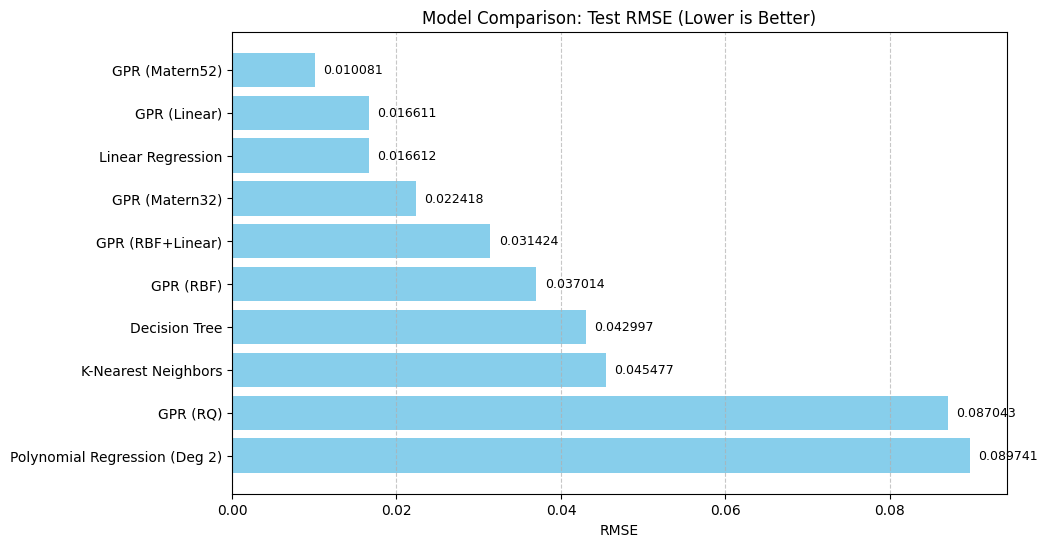

In [33]:
ranking_df_sorted_rmse = ranking_df.sort_values("RMSE", ascending=True)
plt.figure(figsize=(10,6))
bars = plt.barh(ranking_df_sorted_rmse["Model"], ranking_df_sorted_rmse["RMSE"], color='skyblue')
plt.xlabel("RMSE")
plt.title("Model Comparison: Test RMSE (Lower is Better)")
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, f"{width:.6f}", 
             va='center', ha='left', fontsize=9)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()


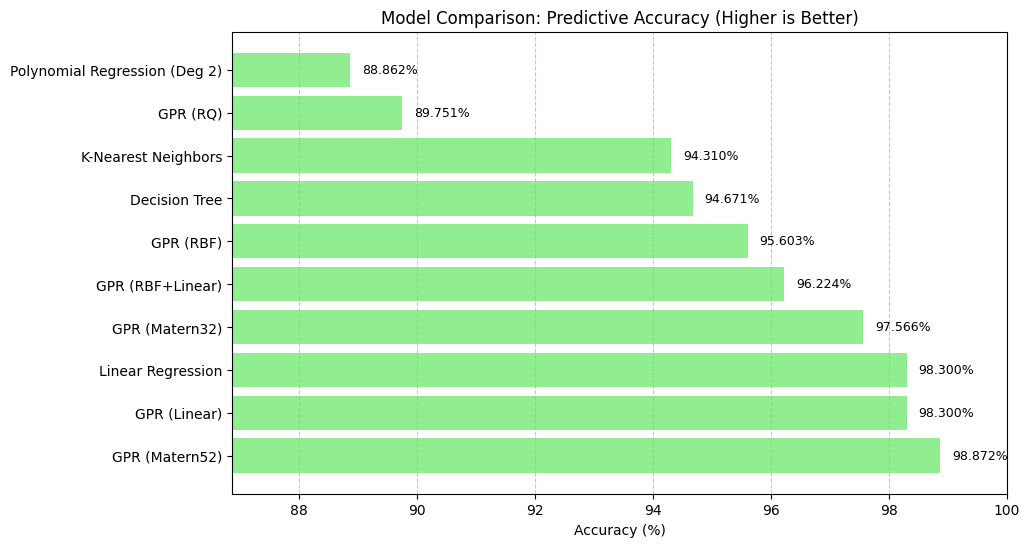

In [34]:
ranking_df_sorted_acc = ranking_df.sort_values("Accuracy (%)", ascending=False)
plt.figure(figsize=(10,6))
bars = plt.barh(ranking_df_sorted_acc["Model"], ranking_df_sorted_acc["Accuracy (%)"], color='lightgreen')
plt.xlabel("Accuracy (%)")
plt.title("Model Comparison: Predictive Accuracy (Higher is Better)")
plt.xlim(ranking_df["Accuracy (%)"].min() - 2, 100)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2, f"{width:.3f}%", 
             va='center', ha='left', fontsize=9)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()
